# Differentiable inference from the Lyα forest

## A compact preliminary pipeline for estimating $(\sigma_8,A_\tau)$

This notebook develops a minimal inference pipeline for the Lyα forest. The goal is to understand the structure of a differentiable inference problem, not to reproduce a full precision analysis.

The complete chain is

$$
\text{CAMELS HDF5 spectra}
\longrightarrow
\tau(x)
\longrightarrow
F(x;A_\tau)=e^{-A_\tau\tau(x)}
\longrightarrow
F_{\mathrm{mock}}(x)
\longrightarrow
P_{\mathrm{1D}}(k)
\longrightarrow
m_\phi(\sigma_8,A_\tau)
\longrightarrow
\chi^2(\sigma_8,A_\tau)
\longrightarrow
p(\sigma_8,A_\tau\mid d).
$$

Here $\sigma_8$ is the cosmological parameter varied by the CAMELS `1P_2` simulations. The parameter $A_\tau$ rescales the optical depth,

$$
\tau_A(x)=A_\tau\tau(x),
\qquad
F(x;A_\tau)=\exp[-A_\tau\tau(x)].
$$

In the Lyα forest, the mean transmitted flux is an important source of uncertainty. Here $A_\tau$ is used as a simple mean-flux-like nuisance parameter. Larger $A_\tau$ produces stronger absorption and a smaller mean transmitted flux.

There are three main differentiable-programming demonstrations:

1. fit a simple double-power-law model to one measured flux power spectrum;
2. train a small differentiable emulator for
   $$
   (\sigma_8,A_\tau)\mapsto \log P_{\mathrm{1D}}(k);
   $$
3. differentiate and optimize a likelihood with respect to both $\sigma_8$ and $A_\tau$.

Once the model and likelihood are written using PyTorch operations, autograd can compute derivatives such as

$$
\frac{\partial \chi^2}{\partial \sigma_8},
\qquad
\frac{\partial \chi^2}{\partial A_\tau}.
$$

This is the conceptual bridge between automatic differentiation and cosmological parameter inference.


## Learning objectives

After completing this notebook, the full workflow should be understandable:

1. Convert Lyα optical depth $\tau$ into transmitted flux $F=\exp(-A_\tau\tau)$.
2. Treat $A_\tau$ as a simple mean-flux-like nuisance parameter.
3. When visually comparing spectra from different $\sigma_8$ simulations, choose $A_\tau$ values that put the spectra on the same mean-flux scale.
4. Add a simple instrumental resolution model and Gaussian flux noise.
5. Compress many one-dimensional spectra into a binned one-dimensional flux power spectrum.
6. Fit a differentiable double-power-law model to one measured power spectrum.
7. Train a small neural-network emulator for
$$
   (\sigma_8,A_\tau) \mapsto \log P_{\mathrm{1D}}(k).
$$
8. Write a Gaussian likelihood for the two-parameter model $(\sigma_8,A_\tau)$.
9. Use PyTorch autograd to differentiate the likelihood with respect to both parameters.
10. Compare autograd derivatives with finite-difference derivatives.
11. Evaluate and visualize a two-dimensional posterior over $(\sigma_8,A_\tau)$.

The important conceptual structure is

$$
\text{physical parameters}
\rightarrow
\text{observable summary}
\rightarrow
\text{likelihood}
\rightarrow
\text{inference}.
$$


## Scope of the calculation

This notebook intentionally keeps the inference problem small. A realistic Lyα forest analysis would require a more complete treatment of continuum fitting, metal contamination, thermal-history parameters, mean-flux calibration, covariance estimation, instrumental systematics, emulator uncertainty, and degeneracies among cosmological and astrophysical parameters.

Here the simplifications and assumptions are:

- one cosmological parameter is varied by the CAMELS sequence, $\sigma_8$;
- one nuisance parameter, $A_\tau$, is applied directly to the optical depth;
- the data vector is the binned one-dimensional flux power spectrum;
- instrumental resolution is represented by a Gaussian smoothing kernel;
- observational noise is represented by independent Gaussian flux noise;
- the likelihood uses a diagonal error model in $\log P_{\mathrm{1D}}$;
- the emulator is a deliberately small neural network trained on the two input parameters $(\sigma_8,A_\tau)$.

The nuisance-parameter treatment is pedagogical. The purpose is to show how a cosmological parameter and an astrophysical parameter can be propagated through the same differentiable inference pipeline.


# 1. Imports and global settings


In [214]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d

import torch
from torch import nn


RANDOM_SEED = 123
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# 2. Data location and simulation table

The notebook assumes that the CAMELS spectra have already been downloaded and placed in a simple directory structure:

```text
data/
  Spectra_004/
    1P_2_n5/Lya-spectra.hdf5
    1P_2_n4/Lya-spectra.hdf5
    ...
    1P_2_5/Lya-spectra.hdf5
```

The `1P_2` sequence varies $\sigma_8$. In this teaching example, the values are written explicitly so that the mapping from simulation name to parameter value is transparent.

The emulator is trained on most of the available $\sigma_8$ values and on a small set of optical-depth amplitudes.

One intermediate value is held out for the final inference test,

$$
\sigma_8 = 0.76.
$$

This held-out value is useful because it tests interpolation rather than memorization.


In [215]:
from pathlib import Path

# Main local data directory.
DATA_ROOT = Path("data")

# CAMELS snapshot used here.
SPECTRA_FOLDER = "Spectra_004"
SPECTRA_FILE = "Lya-spectra.hdf5"

# HDF5 location of the H I Ly-alpha optical-depth array.
TAU_PATH = "/tau/H/1/1215"

# Simulation names and their sigma_8 values.
SIM_TABLE = [
    ("1P_2_n5", 0.60),
    ("1P_2_n4", 0.64),
    ("1P_2_n3", 0.68),
    ("1P_2_n2", 0.72),
    ("1P_2_n1", 0.76),
    ("1P_2_0",  0.80),
    ("1P_2_1",  0.84),
    ("1P_2_2",  0.88),
    ("1P_2_3",  0.92),
    ("1P_2_4",  0.96),
    ("1P_2_5",  1.00),
]

SIGMA8_MIN = 0.60
SIGMA8_MAX = 1.00
SIGMA8_FIDUCIAL = 0.80

# Toy optical-depth-amplitude range used for the nuisance-parameter exercise.
A_TAU_MIN = 0.50
A_TAU_MAX = 1.50
A_TAU_FIDUCIAL = 1.00

# Hold out one intermediate sigma8 value for the final inference test.
# All other sigma8 values are used to train the emulator.
INFERENCE_TEST_SIMS = ["1P_2_n1"]
EMULATOR_TRAINING_SIMS = [
    sim_name for sim_name, _ in SIM_TABLE
    if sim_name not in INFERENCE_TEST_SIMS
]
INFERENCE_COLORS = ["#0072B2"]

SIM_TO_SIGMA8 = dict(SIM_TABLE)


def spectra_file(sim_name):
    """Return the local path to one CAMELS Ly-alpha spectra file."""
    return DATA_ROOT / SPECTRA_FOLDER / sim_name / SPECTRA_FILE


## Check that the expected files are present

Before reading data, it is good practice to verify the local file paths. This prevents later errors from being confused with scientific or numerical problems.


In [216]:
print("Data root:", DATA_ROOT.resolve())
print()

missing_files = []

for sim_name, sigma8 in SIM_TABLE:
    filename = spectra_file(sim_name)
    status = "found" if filename.exists() else "missing"
    print(f"{sim_name:8s}  sigma8={sigma8:.2f}  {status:7s}  {filename}")

    if not filename.exists():
        missing_files.append(filename)

if missing_files:
    raise FileNotFoundError(
        "Some CAMELS spectra files were not found. "
        "Check DATA_ROOT and the directory structure printed above."
    )

Data root: /home/soumak/My_Files/ML4HEP-V4_Differential_Programming/data

1P_2_n5   sigma8=0.60  found    data/Spectra_004/1P_2_n5/Lya-spectra.hdf5
1P_2_n4   sigma8=0.64  found    data/Spectra_004/1P_2_n4/Lya-spectra.hdf5
1P_2_n3   sigma8=0.68  found    data/Spectra_004/1P_2_n3/Lya-spectra.hdf5
1P_2_n2   sigma8=0.72  found    data/Spectra_004/1P_2_n2/Lya-spectra.hdf5
1P_2_n1   sigma8=0.76  found    data/Spectra_004/1P_2_n1/Lya-spectra.hdf5
1P_2_0    sigma8=0.80  found    data/Spectra_004/1P_2_0/Lya-spectra.hdf5
1P_2_1    sigma8=0.84  found    data/Spectra_004/1P_2_1/Lya-spectra.hdf5
1P_2_2    sigma8=0.88  found    data/Spectra_004/1P_2_2/Lya-spectra.hdf5
1P_2_3    sigma8=0.92  found    data/Spectra_004/1P_2_3/Lya-spectra.hdf5
1P_2_4    sigma8=0.96  found    data/Spectra_004/1P_2_4/Lya-spectra.hdf5
1P_2_5    sigma8=1.00  found    data/Spectra_004/1P_2_5/Lya-spectra.hdf5


# 3. Inspect one HDF5 file

An HDF5 file is organized like a small filesystem. It contains groups, datasets, and metadata. Before doing any analysis, it is useful to inspect the file and confirm the dataset path.

For this notebook, the relevant quantity is the Lyα optical depth,

$$
\tau(x).
$$

The transmitted flux fraction is then

$$
F(x;A_\tau)=\exp[-A_\tau\tau(x)].
$$


In [217]:
example_file = spectra_file("1P_2_0")

with h5py.File(example_file, "r") as f:
    print("Top-level HDF5 groups:")
    print(list(f.keys()))
    print()

    print("Expected optical-depth dataset:")
    print(TAU_PATH, "->", TAU_PATH in f)

    if TAU_PATH in f:
        print("tau shape:", f[TAU_PATH].shape)
        print("tau dtype :", f[TAU_PATH].dtype)

    if "Header" in f:
        print("\nHeader attributes:")
        for key, value in f["Header"].attrs.items():
            print(f"  {key}: {value}")


Top-level HDF5 groups:
['Header', 'colden', 'density_weight_density', 'num_important', 'spectra', 'tau', 'tau_obs', 'temperature', 'velocity']

Expected optical-depth dataset:
/tau/H/1/1215 -> True
tau shape: (5000, 2787)
tau dtype : float64

Header attributes:
  box: 25000.0
  discarded: 0
  hubble: 0.6711
  nbins: 2787
  npart: [16477932 16777216        0        0    63762      690]
  omegab: 0.0488408405103218
  omegal: 0.7
  omegam: 0.3
  redshift: 2.9986464259849765


# 4. Read optical depth and convert it to transmitted flux

The functions below implement the first physical step:

$$
\tau(x) \longrightarrow F(x;A_\tau)=e^{-A_\tau\tau(x)}.
$$

The parameter $A_\tau$ rescales the optical depth before the flux is computed. It is a simple way of representing uncertainty in the mean transmitted flux.

When we want a spectrum to have a target mean flux, we determine $A_\tau$ by minimizing

$$
\mathcal{L}(A_\tau)
=
\left[
\left\langle e^{-A_\tau\tau(x)} \right\rangle
-
\overline{F}_{\rm target}
\right]^2.
$$

This is written as a small differentiable optimization problem. We optimize $\log A_\tau$, so that $A_\tau=\exp(\log A_\tau)$ remains positive during the fit.

The returned array is arranged as

```text
(number of sightlines, number of pixels along each sightline)
```

so that each row is one Lyα forest spectrum.


In [218]:
def read_tau(filename, n_sightlines=None):
    """Read Ly-alpha optical depth from one CAMELS HDF5 file."""
    with h5py.File(filename, "r") as f:
        if TAU_PATH not in f:
            raise KeyError(f"{TAU_PATH} was not found in {filename}")
        tau = np.asarray(f[TAU_PATH], dtype=np.float32)

    # We want the convention (n_sightlines, n_pixels).
    # If the stored array looks like (n_pixels, n_sightlines), transpose it.
    if tau.shape[0] < tau.shape[1]:
        tau = tau.T

    if n_sightlines is not None:
        tau = tau[:n_sightlines]

    return tau


def tau_to_flux(tau, A_tau=A_TAU_FIDUCIAL):
    """Convert optical depth to transmitted flux fraction."""
    return np.exp(-A_tau * tau)


def mean_flux_for_A_tau(tau, A_tau):
    """Mean transmitted flux after applying an optical-depth amplitude."""
    return tau_to_flux(tau, A_tau=A_tau).mean()


def optimize_A_tau_for_target_mean_flux(
    tau,
    target_mean_flux,
    start_A_tau=A_TAU_FIDUCIAL,
    n_steps=250,
    learning_rate=0.05,
    return_history=False,
):
    """Choose A_tau by minimizing the mean-flux mismatch with autograd."""
    tau_t = torch.tensor(tau, dtype=torch.float32)
    target_t = torch.tensor(float(target_mean_flux), dtype=torch.float32)

    # Optimizing log(A_tau) keeps A_tau positive without a separate constraint.
    log_A_tau = torch.tensor(
        [np.log(start_A_tau)],
        dtype=torch.float32,
        requires_grad=True,
    )

    optimizer = torch.optim.Adam([log_A_tau], lr=learning_rate)
    history = []

    for _ in range(n_steps):
        optimizer.zero_grad()

        A_tau_t = torch.exp(log_A_tau)
        mean_flux_t = torch.exp(-A_tau_t * tau_t).mean()
        loss = (mean_flux_t - target_t) ** 2

        loss.backward()
        optimizer.step()

        if return_history:
            history.append(
                {
                    "A_tau": float(A_tau_t.detach().item()),
                    "mean_flux": float(mean_flux_t.detach().item()),
                    "loss": float(loss.detach().item()),
                }
            )

    with torch.no_grad():
        A_tau_final = torch.exp(log_A_tau)
        mean_flux_final = torch.exp(-A_tau_final * tau_t).mean()
        loss_final = (mean_flux_final - target_t) ** 2

    if return_history:
        return (
            float(A_tau_final.item()),
            float(mean_flux_final.item()),
            float(loss_final.item()),
            history,
        )

    return float(A_tau_final.item())


tau_demo = read_tau(example_file, n_sightlines=5)
flux_demo = tau_to_flux(tau_demo, A_tau=A_TAU_FIDUCIAL)

print("tau shape :", tau_demo.shape)
print("flux shape:", flux_demo.shape)
print(f"fiducial A_tau: {A_TAU_FIDUCIAL:.2f}")


tau shape : (5, 2787)
flux shape: (5, 2787)
fiducial A_tau: 1.00


# 5. Coordinate along the line of sight

The analysis coordinate in this notebook is the comoving line-of-sight distance,

$$
x \quad [h^{-1}\mathrm{cMpc}].
$$

For a CAMELS box of length $25\,h^{-1}\mathrm{cMpc}$, the pixel width is

$$
\Delta x = \frac{25\,h^{-1}\mathrm{cMpc}}{N_{\mathrm{pix}}}.
$$

The power spectrum will therefore use

$$
k \quad [h\,\mathrm{cMpc}^{-1}].
$$

The only quantity kept in km/s is the instrumental FWHM used when applying a mock spectrograph resolution.


In [219]:
REDSHIFT = 3.0
BOX_SIZE_MPC_H = 25.0
OMEGA_M = 0.30
OMEGA_LAMBDA = 0.70
HUBBLE_H = 0.6711


def comoving_pixel_width(n_pixels):
    """Pixel width along the sightline in h^{-1} cMpc."""
    return BOX_SIZE_MPC_H / n_pixels


def velocity_width_for_resolution(filename, n_pixels):
    """Pixel width in km/s, used only to convert FWHM from km/s to pixels."""
    with h5py.File(filename, "r") as f:
        if "Header" in f:
            header = f["Header"].attrs

            for key in ["dvbin", "dv", "delta_v"]:
                if key in header:
                    value = np.asarray(header[key]).reshape(-1)[0]
                    return float(value)

    # Fallback conversion from comoving length to Hubble velocity at the snapshot redshift.
    # v = H(z) * r_comoving / (1 + z)
    hubble_z = 100.0 * HUBBLE_H * np.sqrt(
        OMEGA_M * (1.0 + REDSHIFT) ** 3 + OMEGA_LAMBDA
    )
    box_size_mpc = BOX_SIZE_MPC_H / HUBBLE_H
    velocity_width_box = hubble_z * box_size_mpc / (1.0 + REDSHIFT)
    return velocity_width_box / n_pixels


n_pixels_demo = flux_demo.shape[1]
dx_demo = comoving_pixel_width(n_pixels_demo)
x_demo = np.arange(n_pixels_demo) * dx_demo
dv_demo = velocity_width_for_resolution(example_file, n_pixels_demo)

print(f"pixel width for analysis   : {dx_demo:.4f} h^-1 cMpc")
print(f"sightline length           : {n_pixels_demo * dx_demo:.2f} h^-1 cMpc")
print(f"pixel width for FWHM only  : {dv_demo:.3f} km/s")


pixel width for analysis   : 0.0090 h^-1 cMpc
sightline length           : 25.00 h^-1 cMpc
pixel width for FWHM only  : 1.000 km/s


## Visual check: same sightline index at different $\sigma_8$

The plot below compares the same array index across the `1P_2` simulations. Since the simulations are part of the same one-parameter sequence, this is a useful visual way to inspect how changing $\sigma_8$ changes the forest in this dataset.

The mean transmitted flux can also change from one simulation to another. To avoid confusing a mean-flux shift with a change in the fluctuation pattern, we choose a different $A_\tau$ for each plotted spectrum so that all spectra have the same mean flux.

The value of $A_\tau$ is found by the differentiable optimization defined above. This keeps the visual calibration consistent with the main theme of the notebook.

The comparison should be interpreted as a diagnostic of the simulation sequence, not as repeated observations of the same astronomical object.


target mean flux for visual comparison: 0.5223
simulation   sigma8   A_tau optimized   mean flux


1P_2_n5    0.60        0.652        0.5223
1P_2_n4    0.64        0.718        0.5223
1P_2_n3    0.68        0.755        0.5223
1P_2_n2    0.72        0.835        0.5223
1P_2_n1    0.76        0.915        0.5223
1P_2_0     0.80        1.000        0.5223
1P_2_1     0.84        1.050        0.5223
1P_2_2     0.88        1.149        0.5223
1P_2_3     0.92        1.232        0.5223
1P_2_4     0.96        1.353        0.5223
1P_2_5     1.00        1.407        0.5223


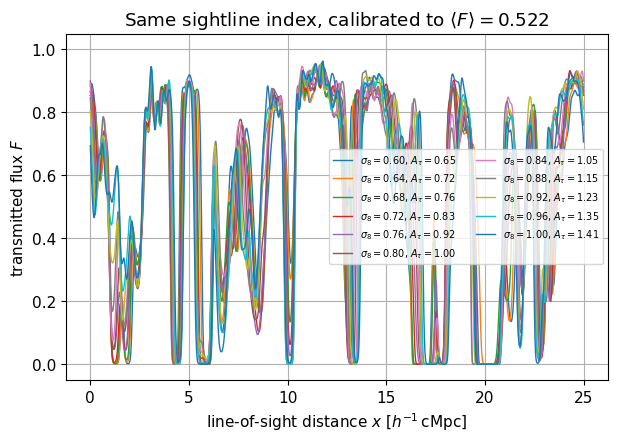

In [220]:
SIGHTLINE_INDEX = 0

# Use the fiducial sigma8 simulation at A_tau=1 to set the visual mean-flux scale.
fiducial_tau_one = read_tau(
    spectra_file("1P_2_0"),
    n_sightlines=SIGHTLINE_INDEX + 1,
)[SIGHTLINE_INDEX : SIGHTLINE_INDEX + 1]
TARGET_MEAN_FLUX_FOR_PLOTS = mean_flux_for_A_tau(fiducial_tau_one, A_TAU_FIDUCIAL)

# Store the calibrated values so that they can be inspected later.
# These values are for the single-sightline visual comparison only.
A_TAU_FOR_VISUAL_COMPARISON = {}

plt.figure()

print(f"target mean flux for visual comparison: {TARGET_MEAN_FLUX_FOR_PLOTS:.4f}")
print("simulation   sigma8   A_tau optimized   mean flux")

for sim_name, sigma8 in SIM_TABLE:
    tau_one = read_tau(
        spectra_file(sim_name),
        n_sightlines=SIGHTLINE_INDEX + 1,
    )[SIGHTLINE_INDEX : SIGHTLINE_INDEX + 1]

    A_tau_plot = optimize_A_tau_for_target_mean_flux(
        tau_one,
        TARGET_MEAN_FLUX_FOR_PLOTS,
        start_A_tau=A_TAU_FIDUCIAL,
    )
    flux_one = tau_to_flux(tau_one, A_tau=A_tau_plot)[0]
    A_TAU_FOR_VISUAL_COMPARISON[sim_name] = A_tau_plot

    print(
        f"{sim_name:8s}   {sigma8:.2f}        "
        f"{A_tau_plot:.3f}        {flux_one.mean():.4f}"
    )

    plt.plot(
        x_demo,
        flux_one,
        lw=1.0,
        label=fr"$\sigma_8={sigma8:.2f}$, $A_\tau={A_tau_plot:.2f}$",
    )

plt.xlabel(r"line-of-sight distance $x$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.ylabel(r"transmitted flux $F$")
plt.title(fr"Same sightline index, calibrated to $\langle F\rangle={TARGET_MEAN_FLUX_FOR_PLOTS:.3f}$")
plt.ylim(-0.05, 1.05)
plt.legend(ncol=2, fontsize=7)
plt.show()


# 6. A simple mock-observation model

The spectra read from the simulation are idealized. To mimic two basic observational effects, we apply:

1. **Instrumental resolution**: a Gaussian smoothing kernel along the sightline.
2. **Flux noise**: independent Gaussian noise in normalized flux units.

The instrumental full width at half maximum is specified in km/s, because spectrograph resolution is often quoted this way. It is converted to pixels only for the smoothing operation. The subsequent analysis remains in $h^{-1}\mathrm{cMpc}$.

For the demonstration plot below we use the fiducial value $A_\tau=1$. Later, when building the emulator dataset, we generate summaries at several values of $A_\tau$.


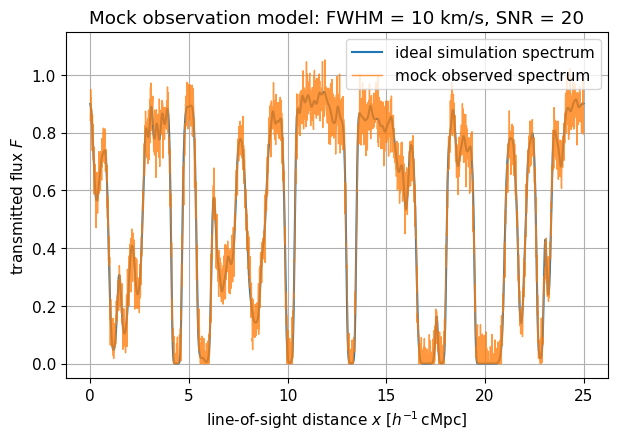

In [221]:
INSTRUMENT_FWHM_KMS = 10.0
SNR = 20.0


def add_mock_observation(
    flux,
    dv_kms,
    random_generator,
    snr=SNR,
    fwhm_kms=INSTRUMENT_FWHM_KMS,
):
    """Apply Gaussian instrumental smoothing and Gaussian flux noise."""
    sigma_kms = fwhm_kms / 2.355
    sigma_pixels = sigma_kms / dv_kms

    smooth_flux = gaussian_filter1d(flux, sigma=sigma_pixels, axis=1, mode="wrap")

    noise_sigma = 1.0 / snr
    noise = random_generator.normal(loc=0.0, scale=noise_sigma, size=smooth_flux.shape)
    noisy_flux = smooth_flux + noise

    return np.clip(noisy_flux, 0.0, 1.5)


demo_rng = np.random.default_rng(RANDOM_SEED)
mock_flux_demo = add_mock_observation(flux_demo, dv_demo, demo_rng)

plt.figure()
plt.plot(x_demo, flux_demo[0], lw=1.5, label="ideal simulation spectrum")
plt.plot(x_demo, mock_flux_demo[0], lw=1.0, alpha=0.8, label="mock observed spectrum")
plt.xlabel(r"line-of-sight distance $x$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.ylabel(r"transmitted flux $F$")
plt.title(fr"Mock observation model: FWHM = {INSTRUMENT_FWHM_KMS:.0f} km/s, SNR = {SNR:.0f}")
plt.ylim(-0.05, 1.15)
plt.legend()
plt.show()


# 7. One-dimensional flux power spectrum

The flux power spectrum summarizes fluctuations along the line of sight. First define the flux contrast,

$$
\delta_F(x)=\frac{F(x)}{\langle F\rangle}-1.
$$

For each sightline, we take a one-dimensional Fourier transform of the flux contrast $\delta_F$ along the line-of-sight direction. 

The squared Fourier amplitude gives the fluctuation power at each line-of-sight wavenumber $k$. 

Averaging this power over sightlines gives the one-dimensional flux power spectrum:

$$
P_{\mathrm{1D}}(k) \propto
\left\langle
\left|\widetilde{\delta_F}(k)\right|^2
\right\rangle.
$$

The precise normalization is not the focus here. The important point is the compression step:

$$
\{\text{many spectra}\}
\longrightarrow
\{P_{\mathrm{1D}}(k_1), P_{\mathrm{1D}}(k_2), \ldots, P_{\mathrm{1D}}(k_N)\}.
$$


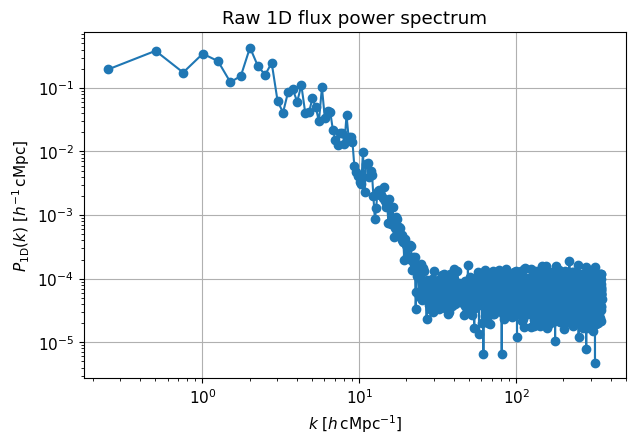

In [222]:
def flux_contrast(flux):
    """Return delta_F = F / <F> - 1."""
    mean_flux = flux.mean()
    return flux / mean_flux - 1.0


def flux_power_1d(flux, dx_mpc_h):
    """Compute a simple 1D flux power spectrum from many sightlines."""
    delta_flux = flux_contrast(flux)

    n_pixels = delta_flux.shape[1]
    box_length = n_pixels * dx_mpc_h

    k = 2.0 * np.pi * np.fft.rfftfreq(n_pixels, d=dx_mpc_h)
    fft_delta = np.fft.rfft(delta_flux, axis=1)

    # Continuous-transform-inspired normalization:
    # P(k) = |dx * FFT(delta_F)|^2 / L.
    power = np.abs(dx_mpc_h * fft_delta) ** 2 / box_length
    mean_power = power.mean(axis=0)

    # Drop the zero mode. It carries no useful fluctuation information here.
    return k[1:], mean_power[1:]


k_demo, power_demo = flux_power_1d(mock_flux_demo, dx_demo)

plt.figure()
plt.loglog(k_demo, power_demo, marker="o")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$P_{\rm 1D}(k)$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.title("Raw 1D flux power spectrum")
plt.show()


## Binning the power spectrum

The raw FFT returns many modes. For inference, it is useful to reduce this to a fixed-length vector of logarithmic $k$-bins:

$$
d =
\left(
\log P_{\mathrm{1D}}(k_1),
\log P_{\mathrm{1D}}(k_2),
\ldots,
\log P_{\mathrm{1D}}(k_N)
\right).
$$

This vector will become both the emulator target and the likelihood data vector.


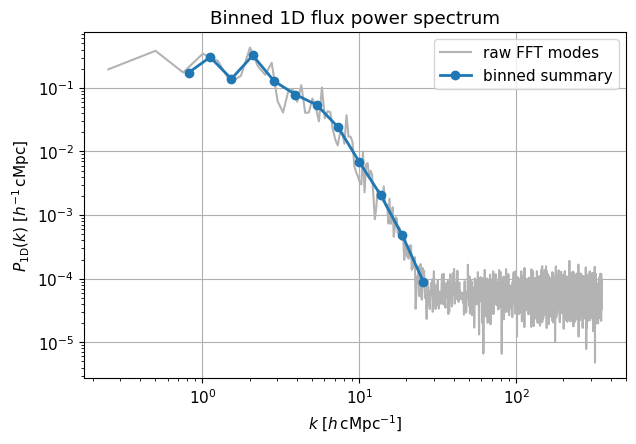

In [223]:
N_K_BINS = 12
K_MIN = 0.70
K_MAX = 30.0

K_EDGES = np.logspace(np.log10(K_MIN), np.log10(K_MAX), N_K_BINS + 1)
K_CENTERS = np.sqrt(K_EDGES[:-1] * K_EDGES[1:])


def bin_power_spectrum(k, power, bin_edges=K_EDGES):
    """Average the power spectrum in fixed logarithmic k-bins."""
    binned_power = []

    log_k = np.log(k)
    log_power = np.log(power + 1.0e-30)

    for k_low, k_high in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (k >= k_low) & (k < k_high)
        has_modes = np.any(in_bin)

        if has_modes:
            bin_mean = power[in_bin].mean()
            binned_power.append(bin_mean)
        else:
            # If a bin has no FFT mode, interpolate in log-log space.
            k_center = np.sqrt(k_low * k_high)
            bin_mean = np.exp(np.interp(np.log(k_center), log_k, log_power))
            binned_power.append(bin_mean)

    return np.asarray(binned_power)


binned_power_demo = bin_power_spectrum(k_demo, power_demo)

plt.figure()
plt.loglog(k_demo, power_demo, color="0.7", label="raw FFT modes")
plt.loglog(K_CENTERS, binned_power_demo, marker="o", lw=2, label="binned summary")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$P_{\rm 1D}(k)$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.title("Binned 1D flux power spectrum")
plt.legend()
plt.show()


# 8. A simple differentiable double-power-law model before emulation

Before training a neural-network emulator, it is useful to practice differentiable modeling on a very small problem.

A single power law is often too restrictive for a Lyα flux power spectrum. Large scales are influenced by cosmological density fluctuations, while smaller scales are affected by thermal broadening, pressure smoothing, peculiar velocities, and instrumental resolution. A simple way to allow a change of slope is a smooth double power law:

$$
P_{\mathrm{model}}(k)
=
A_P
\left(\frac{k}{k_0}\right)^{n_{\rm low}}
\left[
1+
\left(\frac{k}{k_b}\right)^{\Delta n}
\right]^{-1}.
$$

For $k\ll k_b$, the slope is approximately $n_{\rm low}$. For $k\gg k_b$, the slope is approximately $n_{\rm low}-\Delta n$. The parameter $k_b$ therefore marks the scale where the model begins to bend.

This section is still only an exercise. It fits one measured power spectrum and does not replace the simulation-based emulator. Its purpose is to show how a small analytic model can be fitted by gradient descent before moving to the neural-network model.


step   0 | loss = 3.0003e+00 | n_low = -0.530 | n_high = -1.560
step 150 | loss = 1.6019e-01 | n_low = -0.983 | n_high = -4.220
step 300 | loss = 8.5063e-02 | n_low = -0.604 | n_high = -4.554
step 450 | loss = 7.9830e-02 | n_low = -0.452 | n_high = -4.528
step 600 | loss = 7.9408e-02 | n_low = -0.401 | n_high = -4.490

Final fitted double-power-law parameters
log A_P = -2.1566
n_low   = -0.4011
n_high  = -4.4904
k_b     = 5.4305 h cMpc^-1


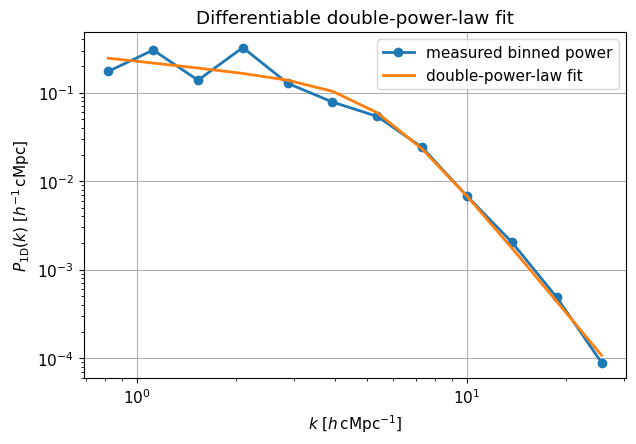

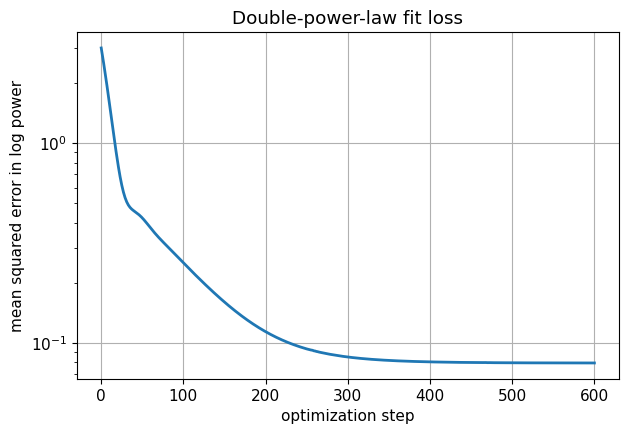

In [224]:
# Target for the double-power-law exercise: one measured binned power spectrum.
log_power_target_t = torch.tensor(np.log(binned_power_demo + 1.0e-12), dtype=torch.float32)
k_t = torch.tensor(K_CENTERS, dtype=torch.float32)

k0 = float(K_CENTERS[len(K_CENTERS) // 2])
k_min = float(K_CENTERS.min())
k_max = float(K_CENTERS.max())

# Trainable parameters of the smooth double power law.
log_A_power = torch.tensor([log_power_target_t.mean().item()], dtype=torch.float32, requires_grad=True)
n_low = torch.tensor([-0.5], dtype=torch.float32, requires_grad=True)
log_k_break = torch.tensor([np.log(k0)], dtype=torch.float32, requires_grad=True)
delta_n = torch.tensor([1.0], dtype=torch.float32, requires_grad=True)

fit_parameters = [log_A_power, n_low, log_k_break, delta_n]
optimizer_dpl = torch.optim.Adam(fit_parameters, lr=0.03)
dpl_loss_history = []


def double_power_law_log_power(k_values):
    """Log of a smooth double-power-law model."""
    k_break = torch.exp(log_k_break)
    bend = torch.log1p((k_values / k_break) ** delta_n)
    return log_A_power + n_low * torch.log(k_values / k0) - bend


for step in range(601):
    optimizer_dpl.zero_grad()

    log_power_model_t = double_power_law_log_power(k_t)
    loss = torch.mean((log_power_model_t - log_power_target_t) ** 2)

    loss.backward()
    optimizer_dpl.step()

    # Keep the bend scale and slope change in a reasonable range.
    with torch.no_grad():
        log_k_break.clamp_(np.log(k_min), np.log(k_max))
        delta_n.clamp_(0.05, 6.0)

    dpl_loss_history.append(loss.item())

    if step % 150 == 0:
        n_high = n_low.item() - delta_n.item()
        print(
            f"step {step:3d} | "
            f"loss = {loss.item():.4e} | "
            f"n_low = {n_low.item():.3f} | "
            f"n_high = {n_high:.3f}"
        )

with torch.no_grad():
    fitted_log_power = double_power_law_log_power(k_t).numpy()
    n_high = n_low.item() - delta_n.item()
    k_break = torch.exp(log_k_break).item()

print("\nFinal fitted double-power-law parameters")
print(f"log A_P = {log_A_power.item():.4f}")
print(f"n_low   = {n_low.item():.4f}")
print(f"n_high  = {n_high:.4f}")
print(f"k_b     = {k_break:.4f} h cMpc^-1")

plt.figure()
plt.plot(K_CENTERS, np.exp(log_power_target_t.numpy()), marker="o", lw=2, label="measured binned power")
plt.plot(K_CENTERS, np.exp(fitted_log_power), lw=2, label="double-power-law fit")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$P_{\rm 1D}(k)$ [$h^{-1}\,\mathrm{cMpc}$]")
plt.title("Differentiable double-power-law fit")
plt.legend()
plt.show()

plt.figure()
plt.semilogy(dpl_loss_history, lw=2)
plt.xlabel("optimization step")
plt.ylabel("mean squared error in log power")
plt.title("Double-power-law fit loss")
plt.show()


# 9. Build the supervised learning dataset

Each CAMELS simulation has a known $\sigma_8$. We now also choose several values of the optical-depth amplitude $A_\tau$ and apply them directly to the same optical-depth fields:

$$
F(x;A_\tau)=\exp[-A_\tau\tau(x)].
$$

For each pair $(\sigma_8,A_\tau)$ we compute noisy estimates of $\log P_{\mathrm{1D}}(k)$ by splitting the sightlines into chunks.

The supervised learning dataset is

$$
\left\{
(\sigma_{8,i},A_{\tau,i}),\ \log P_{\mathrm{1D},i}(k)
\right\}.
$$

This is the point where $A_\tau$ is treated in the same practical way as $\sigma_8$: both are input parameters to the emulator. The first 4000 sightlines are used to construct emulator-training summaries. The last 1000 sightlines are held out for inference tests.


In [225]:
N_SIGHTLINES_PER_SIM = 5000
N_TRAINING_SIGHTLINES = 4000
N_TESTING_SIGHTLINES = 1000
CHUNK_SIZE = 500

# Values used to train the two-parameter emulator.
A_TAU_EMULATOR_VALUES = np.array([0.50, 1.00, 1.50], dtype=np.float32)

# Values used later when evaluating priors/posteriors.
A_TAU_MIN = float(A_TAU_EMULATOR_VALUES.min())
A_TAU_MAX = float(A_TAU_EMULATOR_VALUES.max())

def summarize_flux_chunk(flux_chunk, dx_mpc_h, dv_kms, random_generator):
    """Convert a chunk of spectra into one binned log-power vector."""
    mock_flux = add_mock_observation(flux_chunk, dv_kms, random_generator)
    k, power = flux_power_1d(mock_flux, dx_mpc_h)
    binned_power = bin_power_spectrum(k, power)
    return np.log(binned_power + 1.0e-12)


def split_into_chunks(array, chunk_size):
    """Yield consecutive chunks with the same number of sightlines."""
    n_complete = (array.shape[0] // chunk_size) * chunk_size

    for start in range(0, n_complete, chunk_size):
        stop = start + chunk_size
        yield array[start:stop]


def build_dataset():
    """Build emulator and inference data vectors from all simulations."""
    random_generator = np.random.default_rng(RANDOM_SEED)

    parameter_values = []
    log_power_vectors = []
    simulation_labels = []
    is_held_out = []

    for sim_name, sigma8 in SIM_TABLE:
        filename = spectra_file(sim_name)
        print(f"Processing {sim_name:8s}  sigma8={sigma8:.2f}")

        tau = read_tau(filename, n_sightlines=N_SIGHTLINES_PER_SIM)

        n_pixels = tau.shape[1]
        dx = comoving_pixel_width(n_pixels)
        dv = velocity_width_for_resolution(filename, n_pixels)

        test_start = N_TRAINING_SIGHTLINES
        test_stop = test_start + N_TESTING_SIGHTLINES

        training_tau = tau[:N_TRAINING_SIGHTLINES]
        testing_tau = tau[test_start:test_stop]
        tau_blocks = [(training_tau, False), (testing_tau, True)]

        for A_tau in A_TAU_EMULATOR_VALUES:
            for tau_block, held_out in tau_blocks:
                flux_block = tau_to_flux(tau_block, A_tau=A_tau)

                for flux_chunk in split_into_chunks(flux_block, CHUNK_SIZE):
                    log_power = summarize_flux_chunk(flux_chunk, dx, dv, random_generator)

                    if np.isfinite(log_power).all():
                        parameter_values.append([sigma8, float(A_tau)])
                        log_power_vectors.append(log_power)
                        simulation_labels.append(sim_name)
                        is_held_out.append(held_out)

    return (
        np.asarray(parameter_values, dtype=np.float32),
        np.asarray(log_power_vectors, dtype=np.float32),
        np.asarray(simulation_labels),
        np.asarray(is_held_out, dtype=bool),
    )


X, Y, labels, is_held_out = build_dataset()

emulator_training_mask = (~is_held_out) & np.isin(labels, EMULATOR_TRAINING_SIMS)
inference_test_mask = is_held_out & np.isin(labels, INFERENCE_TEST_SIMS)

print("\nDataset summary")
print("X shape:", X.shape, "  parameter values [sigma8, A_tau]")
print("Y shape:", Y.shape, "  log-power vectors")
print("emulator-training examples:", emulator_training_mask.sum())
print("held-out inference examples:", inference_test_mask.sum())

Processing 1P_2_n5   sigma8=0.60
Processing 1P_2_n4   sigma8=0.64
Processing 1P_2_n3   sigma8=0.68
Processing 1P_2_n2   sigma8=0.72
Processing 1P_2_n1   sigma8=0.76
Processing 1P_2_0    sigma8=0.80
Processing 1P_2_1    sigma8=0.84
Processing 1P_2_2    sigma8=0.88
Processing 1P_2_3    sigma8=0.92
Processing 1P_2_4    sigma8=0.96
Processing 1P_2_5    sigma8=1.00

Dataset summary
X shape: (330, 2)   parameter values [sigma8, A_tau]
Y shape: (330, 12)   log-power vectors
emulator-training examples: 240
held-out inference examples: 6


## How $\sigma_8$ and $A_\tau$ change the summary statistic

The first plot below shows the average binned $\log P_{\mathrm{1D}}(k)$ across the $\sigma_8$ sequence at fixed $A_\tau=1$.

The second plot shows the effect of changing $A_\tau$ at fixed $\sigma_8=0.80$.

Together, these plots show why the emulator should receive both parameters as inputs.


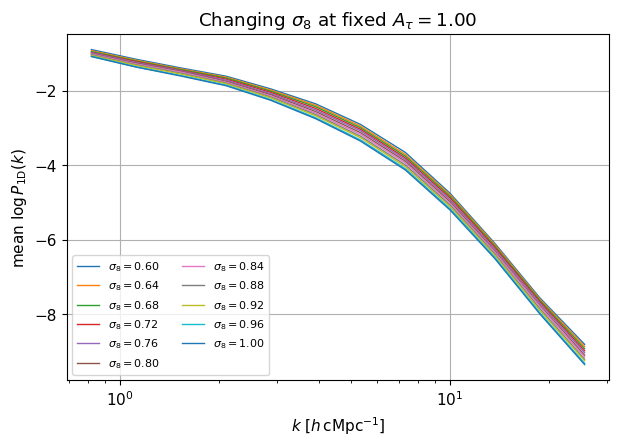

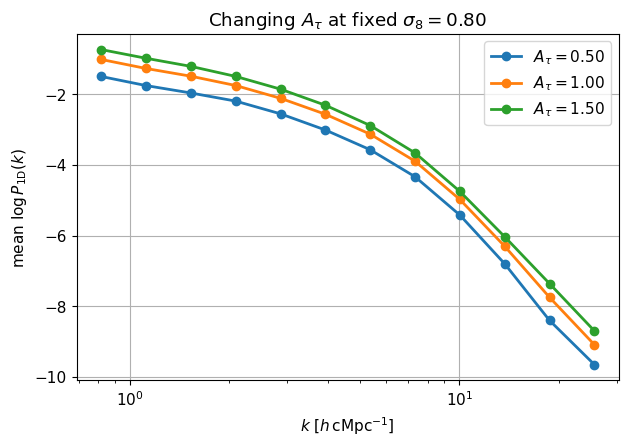

In [226]:
plt.figure()

for sim_name, sigma8 in SIM_TABLE:
    use = (
        (labels == sim_name)
        & (~is_held_out)
        & np.isclose(X[:, 1], A_TAU_FIDUCIAL)
    )
    mean_log_power = Y[use].mean(axis=0)
    plt.plot(K_CENTERS, mean_log_power, lw=1, label=fr"$\sigma_8={sigma8:.2f}$")

plt.xscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"mean $\log P_{\rm 1D}(k)$")
plt.title(fr"Changing $\sigma_8$ at fixed $A_\tau={A_TAU_FIDUCIAL:.2f}$")
plt.legend(ncol=2, fontsize=8)
plt.show()


plt.figure()

for A_tau in A_TAU_EMULATOR_VALUES:
    use = (
        (labels == "1P_2_0")
        & (~is_held_out)
        & np.isclose(X[:, 1], A_tau)
    )
    mean_log_power = Y[use].mean(axis=0)
    plt.plot(K_CENTERS, mean_log_power, marker="o", lw=2, label=fr"$A_\tau={A_tau:.2f}$")

plt.xscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"mean $\log P_{\rm 1D}(k)$")
plt.title(fr"Changing $A_\tau$ at fixed $\sigma_8={SIGMA8_FIDUCIAL:.2f}$")
plt.legend()
plt.show()

# 10. Train a differentiable emulator

The emulator is a small neural network that learns the relation

$$
m_\phi:(\sigma_8,A_\tau) \mapsto \log P_{\mathrm{1D}}(k).
$$

In this notebook, `X` and `Y` are the supervised-learning dataset for that relation. They are paired row by row:

$$
X_i \longleftrightarrow Y_i.
$$

One row corresponds to one chunk of sightlines from one CAMELS simulation at one value of $A_\tau$.

For one chunk:

1. the simulation has one known value of $\sigma_8$;
2. we choose one value of $A_\tau$ and apply it to the optical depth;
3. those sightlines are converted into one binned power-spectrum vector;
4. the input row is

$$
X_i = [\sigma_8,A_\tau];
$$

5. the target row is

$$
Y_i =
[\log P_{\mathrm{1D}}(k_1),
 \log P_{\mathrm{1D}}(k_2),
 \ldots,
 \log P_{\mathrm{1D}}(k_N)].
$$

Thus `X` stores the input parameter labels, and `Y` stores the measured summary statistic that the emulator should predict.


In [227]:
X_emulator = X[emulator_training_mask]
Y_emulator = Y[emulator_training_mask]

split_rng = np.random.default_rng(RANDOM_SEED)
permutation = split_rng.permutation(len(X_emulator))

n_train = int(0.8 * len(permutation))
train_indices = permutation[:n_train]
validation_indices = permutation[n_train:]

X_train = X_emulator[train_indices]
Y_train = Y_emulator[train_indices]
X_validation = X_emulator[validation_indices]
Y_validation = Y_emulator[validation_indices]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_validation_t = torch.tensor(X_validation, dtype=torch.float32)
Y_validation_t = torch.tensor(Y_validation, dtype=torch.float32)

print("training examples  :", len(X_train))
print("validation examples:", len(X_validation))
print("output dimension   :", Y.shape[1])


training examples  : 192
validation examples: 48
output dimension   : 12


## What the training loop minimizes

After the train/validation split, `X_train_t` and `Y_train_t` are the PyTorch versions of the paired training rows:

```text
X_train_t[j]  ->  [sigma8, A_tau] for one chunk
Y_train_t[j]  ->  log-power vector for the same chunk
```

The model prediction

```python
prediction = emulator(X_train_t)
```

has the same shape as `Y_train_t`. The loss is the mean squared error between the predicted and target log-power vectors,

$$
\mathrm{loss}
=
\left\langle
\left(m_\phi(\sigma_8,A_\tau)-\log P_{\mathrm{1D}}\right)^2
\right\rangle.
$$

During this loop, `loss.backward()` computes gradients with respect to the neural-network weights $\phi$, and `optimizer.step()` updates those weights. The physical parameter values in `X_train_t` are fixed labels in this section.


In [228]:
emulator = nn.Sequential(
    nn.Linear(2, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, Y.shape[1]),
)

optimizer = torch.optim.Adam(emulator.parameters(), lr=1.0e-2)

train_losses = []
validation_losses = []
recorded_epochs = []

for epoch in range(1201):
    emulator.train()
    optimizer.zero_grad()

    prediction = emulator(X_train_t)
    loss = torch.mean((prediction - Y_train_t) ** 2)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        emulator.eval()
        with torch.no_grad():
            validation_prediction = emulator(X_validation_t)
            validation_loss = torch.mean((validation_prediction - Y_validation_t) ** 2)

        recorded_epochs.append(epoch)
        train_losses.append(loss.item())
        validation_losses.append(validation_loss.item())

        if epoch % 200 == 0:
            print(
                f"epoch {epoch:4d} | "
                f"train loss = {loss.item():.4e} | "
                f"validation loss = {validation_loss.item():.4e}"
            )

epoch    0 | train loss = 2.0910e+01 | validation loss = 1.9266e+01
epoch  200 | train loss = 7.3994e-03 | validation loss = 7.9793e-03
epoch  400 | train loss = 2.6655e-03 | validation loss = 2.9541e-03
epoch  600 | train loss = 1.9903e-03 | validation loss = 2.2421e-03
epoch  800 | train loss = 1.6082e-03 | validation loss = 1.8178e-03
epoch 1000 | train loss = 1.2508e-03 | validation loss = 1.4111e-03
epoch 1200 | train loss = 1.0522e-03 | validation loss = 1.1822e-03


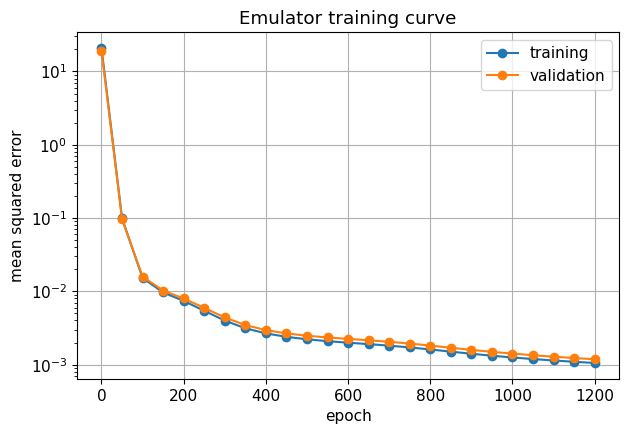

In [229]:
plt.figure()
plt.semilogy(recorded_epochs, train_losses, marker="o", label="training")
plt.semilogy(recorded_epochs, validation_losses, marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("mean squared error")
plt.title("Emulator training curve")
plt.legend()
plt.show()

## Emulator prediction in physical units

The neural network now works directly in the physical units used by the dataset. Its inputs are $(\sigma_8,A_\tau)$, and its output is the predicted $\log P_{\mathrm{1D}}(k)$ vector.

The function `emulator_log_power_torch` is the differentiable forward model used later in the likelihood:

$$
(\sigma_8,A_\tau)
\longrightarrow
\text{neural network}
\longrightarrow
\log P_{\mathrm{1D}}(k).
$$

The NumPy wrapper is only for plotting. The PyTorch function is used for differentiable inference.


In [230]:
def emulator_log_power_torch(sigma8, A_tau):
    """Differentiable prediction: (sigma8, A_tau) -> log P_1D(k)."""
    parameter_row = torch.stack(
        [sigma8.reshape(-1)[0], A_tau.reshape(-1)[0]]
    ).reshape(1, 2)
    return emulator(parameter_row).reshape(-1)


def emulator_log_power_numpy(sigma8, A_tau=A_TAU_FIDUCIAL):
    """Numpy wrapper for plotting emulator predictions."""
    emulator.eval()

    with torch.no_grad():
        sigma8_t = torch.tensor([sigma8], dtype=torch.float32)
        A_tau_t = torch.tensor([A_tau], dtype=torch.float32)
        return emulator_log_power_torch(sigma8_t, A_tau_t).numpy()

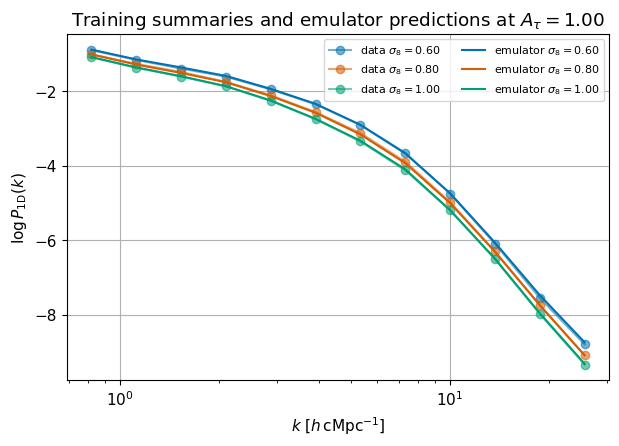

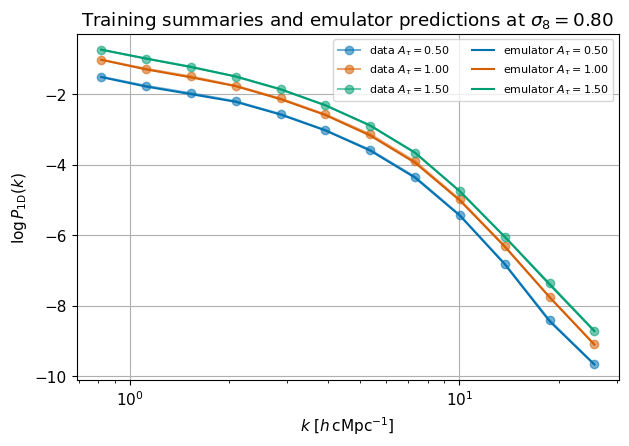

In [231]:
plt.figure()

sim_names = ["1P_2_n5", "1P_2_0", "1P_2_5"]
colors = ["#0072B2", "#D55E00", "#009E73"]

for sim_name, color in zip(sim_names, colors):
    sigma8 = SIM_TO_SIGMA8[sim_name]
    use = (
        (labels == sim_name)
        & emulator_training_mask
        & np.isclose(X[:, 1], A_TAU_FIDUCIAL)
    )

    plt.plot(
        K_CENTERS,
        Y[use].mean(axis=0),
        marker="o",
        alpha=0.55,
        color=color,
        label=fr"data $\sigma_8={sigma8:.2f}$",
    )

for sigma8, color in zip([0.60, 0.80, 1.00], colors):
    prediction = emulator_log_power_numpy(sigma8, A_tau=A_TAU_FIDUCIAL)

    plt.plot(
        K_CENTERS,
        prediction,
        lw=1.5,
        color=color,
        label=fr"emulator $\sigma_8={sigma8:.2f}$",
    )

plt.xscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$\log P_{\rm 1D}(k)$")
plt.title(fr"Training summaries and emulator predictions at $A_\tau={A_TAU_FIDUCIAL:.2f}$")
plt.legend(ncol=2, fontsize=8)
plt.show()


plt.figure()

for A_tau, color in zip(A_TAU_EMULATOR_VALUES, colors):
    use = (
        (labels == "1P_2_0")
        & emulator_training_mask
        & np.isclose(X[:, 1], A_tau)
    )

    plt.plot(
        K_CENTERS,
        Y[use].mean(axis=0),
        marker="o",
        alpha=0.55,
        color=color,
        label=fr"data $A_\tau={A_tau:.2f}$",
    )

for A_tau, color in zip(A_TAU_EMULATOR_VALUES, colors):
    prediction = emulator_log_power_numpy(SIGMA8_FIDUCIAL, A_tau=A_tau)

    plt.plot(
        K_CENTERS,
        prediction,
        lw=1.5,
        color=color,
        label=fr"emulator $A_\tau={A_tau:.2f}$",
    )

plt.xscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$\log P_{\rm 1D}(k)$")
plt.title(fr"Training summaries and emulator predictions at $\sigma_8={SIGMA8_FIDUCIAL:.2f}$")
plt.legend(ncol=2, fontsize=8)
plt.show()

# 11. Likelihood for $(\sigma_8,A_\tau)$

The emulator is now a direct two-parameter model:

$$
m_\phi(\sigma_8,A_\tau)=\log P_{\mathrm{1D}}(k;\sigma_8,A_\tau).
$$

For an observed summary vector

$$
d_{\mathrm{obs}}=\log P_{\mathrm{1D}}^{\mathrm{obs}}(k),
$$

we use the diagonal Gaussian form

$$
\chi^2(\sigma_8,A_\tau)
=
\sum_i
\left[
\frac{d_{\mathrm{obs},i}-m_{\phi,i}(\sigma_8,A_\tau)}{s_i}
\right]^2.
$$

The quantities $s_i$ are empirical scale factors estimated from the training chunks. In a precision analysis, this would be replaced by a carefully estimated covariance matrix.


In [232]:
# Empirical diagonal uncertainty model for the likelihood.
sigma_log_power = Y_emulator.std(axis=0)
sigma_log_power = np.maximum(sigma_log_power, 0.05)
sigma_log_power_t = torch.tensor(sigma_log_power, dtype=torch.float32)


def model_log_power_torch(sigma8, A_tau):
    """Two-parameter emulator model for log P_1D(k)."""
    return emulator_log_power_torch(sigma8, A_tau)


def model_log_power_numpy(sigma8, A_tau=A_TAU_FIDUCIAL):
    """Numpy wrapper for plotting the two-parameter toy model."""
    emulator.eval()

    with torch.no_grad():
        sigma8_t = torch.tensor([sigma8], dtype=torch.float32)
        A_tau_t = torch.tensor([A_tau], dtype=torch.float32)
        return model_log_power_torch(sigma8_t, A_tau_t).numpy()


def chi2_for_observation(sigma8, A_tau, observed_log_power):
    """Differentiable chi-square for one observed log-power vector."""
    observation_t = torch.tensor(observed_log_power, dtype=torch.float32)
    model_prediction = model_log_power_torch(sigma8, A_tau)
    residual = (observation_t - model_prediction) / sigma_log_power_t
    return torch.sum(residual ** 2)


def testing_tau_for_simulation(sim_name):
    """Read the held-out sightlines for one simulation."""
    tau = read_tau(spectra_file(sim_name), n_sightlines=N_SIGHTLINES_PER_SIM)
    test_start = N_TRAINING_SIGHTLINES
    test_stop = test_start + N_TESTING_SIGHTLINES
    return tau[test_start:test_stop]


def observed_log_power_for_simulation(sim_name, A_tau, seed_offset=0):
    """Create one held-out observed log-power vector at the chosen A_tau."""
    filename = spectra_file(sim_name)
    tau = testing_tau_for_simulation(sim_name)

    n_pixels = tau.shape[1]
    dx = comoving_pixel_width(n_pixels)
    dv = velocity_width_for_resolution(filename, n_pixels)

    flux = tau_to_flux(tau, A_tau=A_tau)
    random_generator = np.random.default_rng(RANDOM_SEED + 1000 + seed_offset)

    log_power_vectors = []
    for flux_chunk in split_into_chunks(flux, CHUNK_SIZE):
        log_power = summarize_flux_chunk(flux_chunk, dx, dv, random_generator)
        if np.isfinite(log_power).all():
            log_power_vectors.append(log_power)

    return np.asarray(log_power_vectors).mean(axis=0), len(log_power_vectors)


# The posterior example uses the single held-out sigma8 value.
# A_tau is first calibrated so that the held-out spectra have the same
# mean flux as the fiducial sigma8=0.80 case at A_tau=1.
INFERENCE_TARGET_SIMS = INFERENCE_TEST_SIMS

fiducial_testing_tau = testing_tau_for_simulation("1P_2_0")
TARGET_MEAN_FLUX_FOR_INFERENCE = mean_flux_for_A_tau(
    fiducial_testing_tau,
    A_TAU_FIDUCIAL,
)

inference_cases = []

print(f"target mean flux for inference: {TARGET_MEAN_FLUX_FOR_INFERENCE:.4f}")
print("Held-out likelihood test:")

for case_number, (sim_name, color) in enumerate(zip(INFERENCE_TARGET_SIMS, INFERENCE_COLORS)):
    true_sigma8 = SIM_TO_SIGMA8[sim_name]
    testing_tau = testing_tau_for_simulation(sim_name)

    matched_A_tau = optimize_A_tau_for_target_mean_flux(
        testing_tau,
        TARGET_MEAN_FLUX_FOR_INFERENCE,
        start_A_tau=A_TAU_FIDUCIAL,
        n_steps=300,
    )

    if matched_A_tau < A_TAU_MIN or matched_A_tau > A_TAU_MAX:
        raise ValueError(
            f"The matched A_tau={matched_A_tau:.3f} for {sim_name} lies outside "
            f"the emulator range [{A_TAU_MIN:.2f}, {A_TAU_MAX:.2f}]."
        )

    observed_log_power, n_chunks = observed_log_power_for_simulation(
        sim_name,
        matched_A_tau,
        seed_offset=case_number,
    )

    true_sigma8_t = torch.tensor([true_sigma8], dtype=torch.float32)
    true_A_tau_t = torch.tensor([matched_A_tau], dtype=torch.float32)
    chi2_at_true_parameters = chi2_for_observation(
        true_sigma8_t,
        true_A_tau_t,
        observed_log_power,
    ).item()

    inference_cases.append(
        {
            "sim_name": sim_name,
            "true_sigma8": true_sigma8,
            "true_A_tau": matched_A_tau,
            "target_mean_flux": TARGET_MEAN_FLUX_FOR_INFERENCE,
            "observed_mean_flux": mean_flux_for_A_tau(testing_tau, matched_A_tau),
            "chi2_at_true_parameters": chi2_at_true_parameters,
            "n_chunks": n_chunks,
            "observed_log_power": observed_log_power,
            "color": color,
        }
    )

    print(
        f"{sim_name:8s}  "
        f"true sigma8 = {true_sigma8:.2f}  "
        f"matched A_tau = {matched_A_tau:.4f}  "
        f"mean flux = {mean_flux_for_A_tau(testing_tau, matched_A_tau):.4f}  "
        f"chi2(true parameters) = {chi2_at_true_parameters:.4f}"
    )


target mean flux for inference: 0.5537
Held-out likelihood test:
1P_2_n1   true sigma8 = 0.76  matched A_tau = 0.9360  mean flux = 0.5537  chi2(true parameters) = 0.0892


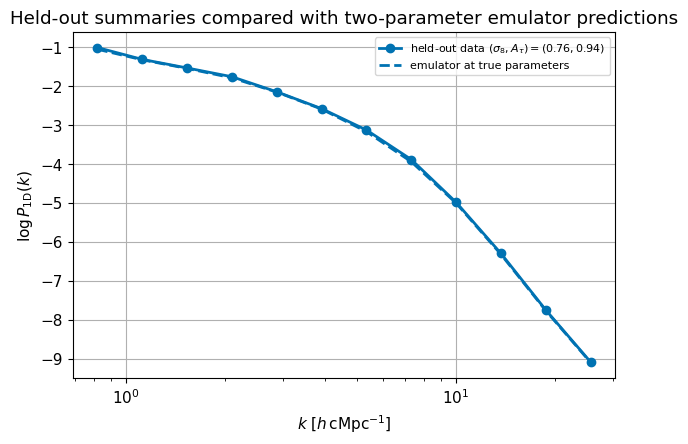

In [233]:
plt.figure()

for case in inference_cases:
    sigma8 = case["true_sigma8"]
    A_tau = case["true_A_tau"]
    color = case["color"]
    plt.plot(
        K_CENTERS,
        case["observed_log_power"],
        marker="o",
        lw=2,
        color=color,
        label=fr"held-out data $(\sigma_8,A_\tau)=({sigma8:.2f},{A_tau:.2f})$",
    )

    model_prediction = model_log_power_numpy(sigma8, A_tau)
    plt.plot(
        K_CENTERS,
        model_prediction,
        linestyle="--",
        lw=2,
        color=color,
        label=fr"emulator at true parameters",
    )

plt.xscale("log")
plt.xlabel(r"$k$ [$h\,\mathrm{cMpc}^{-1}$]")
plt.ylabel(r"$\log P_{\rm 1D}(k)$")
plt.title("Held-out summaries compared with two-parameter emulator predictions")
plt.legend(fontsize=8)
plt.show()

# 12. Autograd: differentiating the likelihood

Up to this point, we have trained the emulator and defined a two-parameter likelihood. The model is now treated as a fixed differentiable function of two parameters:

$$
(\sigma_8,A_\tau)
\longrightarrow
m(\sigma_8,A_\tau)
\longrightarrow
\chi^2(\sigma_8,A_\tau).
$$

The question we now ask is: for this observed held-out power spectrum, how should $\sigma_8$ and $A_\tau$ change in order to reduce the mismatch between the data and the model?

PyTorch can compute both components of the gradient,

$$
\nabla\chi^2
=
\left(
\frac{\partial\chi^2}{\partial\sigma_8},
\frac{\partial\chi^2}{\partial A_\tau}
\right).
$$

To make this possible, the trial values of $\sigma_8$ and $A_\tau$ are created as PyTorch tensors with `requires_grad=True`. When we call `.backward()` on $\chi^2$, PyTorch differentiates the likelihood with respect to these input parameters. The derivative is with respect to the physical parameters, not with respect to the neural-network weights.


In [234]:
emulator.eval()

primary_case = inference_cases[0]

sigma8_trial = torch.tensor([SIGMA8_FIDUCIAL], dtype=torch.float32, requires_grad=True)
A_tau_trial = torch.tensor([1.00], dtype=torch.float32, requires_grad=True)

chi2_trial = chi2_for_observation(
    sigma8_trial,
    A_tau_trial,
    primary_case["observed_log_power"],
)

chi2_trial.backward()

print(f"trial sigma8              : {sigma8_trial.item():.4f}")
print(f"trial A_tau               : {A_tau_trial.item():.4f}")
print(f"chi2(sigma8, A_tau)       : {chi2_trial.item():.4f}")
print(f"d chi2 / d sigma8         : {sigma8_trial.grad.item():.4f}")
print(f"d chi2 / d A_tau          : {A_tau_trial.grad.item():.4f}")

trial sigma8              : 0.8000
trial A_tau               : 1.0000
chi2(sigma8, A_tau)       : 0.0573
d chi2 / d sigma8         : 2.2062
d chi2 / d A_tau          : -1.2033


# 13. Finite differences versus autograd

A useful check is to compare the autograd derivative with a central finite-difference estimate. For example,

$$
\frac{\partial\chi^2}{\partial\sigma_8}
\approx
\frac{
\chi^2(\sigma_8+\epsilon,A_\tau)
-
\chi^2(\sigma_8-\epsilon,A_\tau)
}{2\epsilon}.
$$

A similar expression can be written for $A_\tau$. Finite differences require choosing a step size $\epsilon$. If $\epsilon$ is too large, the estimate suffers from truncation error. If $\epsilon$ is too small, the subtraction can become numerically noisy. Autograd avoids this step-size choice for differentiable operations.


epsilon      fd dchi2/dsigma8    fd dchi2/dA_tau
 1.0e-05           2.207048          -1.200289
 3.2e-05           2.214186          -1.194533
 1.0e-04           2.206527          -1.202729
 3.2e-04           2.205303          -1.203356
 1.0e-03           2.205916          -1.203313
 3.2e-03           2.204377          -1.204213
 1.0e-02           2.188348          -1.212325
 3.2e-02           2.028026          -1.293343
 1.0e-01           0.411691          -2.093034


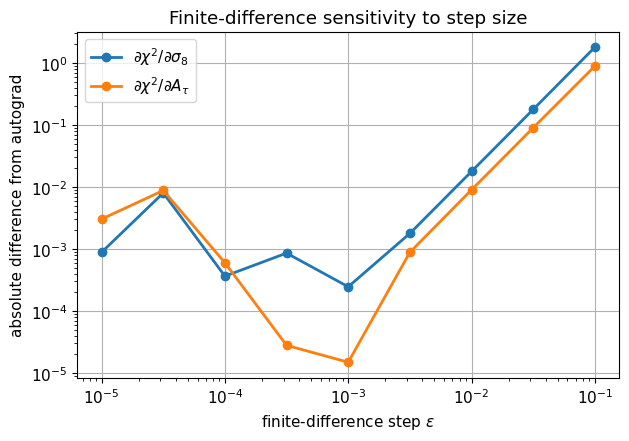

In [235]:
def chi2_float(sigma8_value, A_tau_value, observed_log_power):
    """Evaluate chi-square using ordinary Python floats."""
    sigma8_t = torch.tensor([sigma8_value], dtype=torch.float32)
    A_tau_t = torch.tensor([A_tau_value], dtype=torch.float32)

    with torch.no_grad():
        return chi2_for_observation(sigma8_t, A_tau_t, observed_log_power).item()


def central_difference_sigma8(sigma8_value, A_tau_value, observed_log_power, epsilon):
    """Central finite difference for d chi2 / d sigma8."""
    plus = chi2_float(sigma8_value + epsilon, A_tau_value, observed_log_power)
    minus = chi2_float(sigma8_value - epsilon, A_tau_value, observed_log_power)
    return (plus - minus) / (2.0 * epsilon)


def central_difference_A_tau(sigma8_value, A_tau_value, observed_log_power, epsilon):
    """Central finite difference for d chi2 / d A_tau."""
    plus = chi2_float(sigma8_value, A_tau_value + epsilon, observed_log_power)
    minus = chi2_float(sigma8_value, A_tau_value - epsilon, observed_log_power)
    return (plus - minus) / (2.0 * epsilon)


sigma8_value = sigma8_trial.item()
A_tau_value = A_tau_trial.item()
observed_log_power = primary_case["observed_log_power"]

autograd_sigma8 = sigma8_trial.grad.item()
autograd_A_tau = A_tau_trial.grad.item()

epsilon_values = np.logspace(-5, -1, 9)
finite_difference_sigma8 = []
finite_difference_A_tau = []

print("epsilon      fd dchi2/dsigma8    fd dchi2/dA_tau")

for epsilon in epsilon_values:
    fd_sigma8 = central_difference_sigma8(
        sigma8_value,
        A_tau_value,
        observed_log_power,
        epsilon,
    )
    fd_A_tau = central_difference_A_tau(
        sigma8_value,
        A_tau_value,
        observed_log_power,
        epsilon,
    )

    finite_difference_sigma8.append(fd_sigma8)
    finite_difference_A_tau.append(fd_A_tau)

    print(f"{epsilon:8.1e}   {fd_sigma8:16.6f}   {fd_A_tau:16.6f}")

finite_difference_sigma8 = np.asarray(finite_difference_sigma8)
finite_difference_A_tau = np.asarray(finite_difference_A_tau)

plt.figure()
plt.loglog(
    epsilon_values,
    np.abs(finite_difference_sigma8 - autograd_sigma8) + 1.0e-30,
    marker="o",
    lw=2,
    label=r"$\partial\chi^2/\partial\sigma_8$",
)
plt.loglog(
    epsilon_values,
    np.abs(finite_difference_A_tau - autograd_A_tau) + 1.0e-30,
    marker="o",
    lw=2,
    label=r"$\partial\chi^2/\partial A_\tau$",
)
plt.xlabel(r"finite-difference step $\epsilon$")
plt.ylabel("absolute difference from autograd")
plt.title("Finite-difference sensitivity to step size")
plt.legend()
plt.show()


# 14. Gradient-based two-parameter inference

We now use the derivatives from the previous sections to estimate both $\sigma_8$ and $A_\tau$. For a Gaussian likelihood,

$$
-
\log p(d_{\mathrm{obs}}\mid \sigma_8,A_\tau)
=
\frac{1}{2}\chi^2(\sigma_8,A_\tau)
+
\mathrm{constant}.
$$

The constant does not depend on the parameters, so maximizing the likelihood is equivalent to minimizing

$$
\frac{1}{2}\chi^2(\sigma_8,A_\tau).
$$

The optimizer below acts on a two-component tensor,

$$
\theta=(\sigma_8,A_\tau).
$$

At each step, PyTorch computes the gradient of the objective with respect to both components. The clamping step keeps the parameters inside the range where this toy model is intended to be used.

The important difference from a one-parameter example is that the optimizer can now move in a two-dimensional parameter space. This allows the nuisance parameter to partly compensate changes in the cosmological parameter.


In [236]:
def run_gradient_inference(
    observed_log_power,
    start_sigma8=SIGMA8_FIDUCIAL,
    start_A_tau=A_TAU_FIDUCIAL,
    n_steps=301,
    learning_rate=0.02,
):
    """Estimate sigma8 and A_tau by minimizing 0.5 * chi2."""
    parameters = torch.tensor(
        [start_sigma8, start_A_tau],
        dtype=torch.float32,
        requires_grad=True,
    )
    optimizer = torch.optim.Adam([parameters], lr=learning_rate)

    for _ in range(n_steps):
        optimizer.zero_grad()

        sigma8_fit = parameters[0].reshape(1)
        A_tau_fit = parameters[1].reshape(1)
        objective = 0.5 * chi2_for_observation(
            sigma8_fit,
            A_tau_fit,
            observed_log_power,
        )

        objective.backward()
        optimizer.step()

        with torch.no_grad():
            parameters[0].clamp_(SIGMA8_MIN, SIGMA8_MAX)
            parameters[1].clamp_(A_TAU_MIN, A_TAU_MAX)

    return {
        "sigma8_estimate": parameters[0].item(),
        "A_tau_estimate": parameters[1].item(),
        "final_objective": objective.item(),
    }


for case in inference_cases:
    result = run_gradient_inference(case["observed_log_power"])
    case.update(result)

    print(
        f"{case['sim_name']:8s} | "
        f"true (sigma8, A_tau) = ({case['true_sigma8']:.2f}, {case['true_A_tau']:.2f}) | "
        f"gradient estimate = ({case['sigma8_estimate']:.4f}, {case['A_tau_estimate']:.4f})"
    )


1P_2_n1  | true (sigma8, A_tau) = (0.76, 0.94) | gradient estimate = (0.7482, 0.9519)


# 15. Two-dimensional posterior grid

The final diagnostic is a two-dimensional posterior over $\sigma_8$ and $A_\tau$. We show this posterior for the single held-out case

$$
\sigma_8=0.76.
$$

The value of $A_\tau$ is not chosen arbitrarily. It is first determined by the same differentiable mean-flux calibration used earlier in the notebook. In other words, for the held-out simulation we choose $A_\tau$ so that

$$
\left\langle e^{-A_\tau \tau} \right\rangle
=
\overline{F}_{\rm target},
$$

where the target mean flux is taken from the fiducial $\sigma_8=0.80$ simulation at $A_\tau=1$.

Assuming flat priors over the allowed ranges,

$$
p(\sigma_8,A_\tau\mid d)
\propto
\exp\left[-\frac{1}{2}\chi^2(\sigma_8,A_\tau)\right].
$$

This grid calculation is not needed for autograd. It is included because the posterior shows the degeneracy between the cosmological parameter and the nuisance parameter. If changing $A_\tau$ can partly mimic changing $\sigma_8$, the posterior contours will be elongated or tilted.


In [237]:
sigma8_grid = np.linspace(SIGMA8_MIN, SIGMA8_MAX, 181)
A_tau_grid = np.linspace(A_TAU_MIN, A_TAU_MAX, 181)

d_sigma8 = sigma8_grid[1] - sigma8_grid[0]
d_A_tau = A_tau_grid[1] - A_tau_grid[0]
posterior_cell_area = d_sigma8 * d_A_tau


def posterior_density_level(posterior, mass):
    """Density threshold enclosing the requested posterior mass."""
    sorted_density = np.sort(posterior.ravel())[::-1]
    cumulative_mass = np.cumsum(sorted_density) * posterior_cell_area
    index = np.searchsorted(cumulative_mass, mass)
    index = min(index, len(sorted_density) - 1)
    return sorted_density[index]


def posterior_grid_2d(observed_log_power):
    """Evaluate the normalized posterior on a two-dimensional grid."""
    chi2_values = np.empty((len(A_tau_grid), len(sigma8_grid)))

    emulator.eval()
    with torch.no_grad():
        for i, A_tau in enumerate(A_tau_grid):
            A_tau_t = torch.tensor([A_tau], dtype=torch.float32)

            for j, sigma8 in enumerate(sigma8_grid):
                sigma8_t = torch.tensor([sigma8], dtype=torch.float32)
                chi2_values[i, j] = chi2_for_observation(
                    sigma8_t,
                    A_tau_t,
                    observed_log_power,
                ).item()

    delta_chi2 = chi2_values - chi2_values.min()
    posterior = np.exp(-0.5 * delta_chi2)

    # Normalize the posterior density on the rectangular grid.
    posterior = posterior / (posterior.sum() * posterior_cell_area)

    map_i, map_j = np.unravel_index(np.argmax(posterior), posterior.shape)

    posterior_sigma8 = posterior.sum(axis=0) * d_A_tau
    posterior_A_tau = posterior.sum(axis=1) * d_sigma8

    posterior_sigma8 = posterior_sigma8 / (posterior_sigma8.sum() * d_sigma8)
    posterior_A_tau = posterior_A_tau / (posterior_A_tau.sum() * d_A_tau)

    cdf_sigma8 = np.cumsum(posterior_sigma8) * d_sigma8
    cdf_A_tau = np.cumsum(posterior_A_tau) * d_A_tau

    return {
        "posterior_2d": posterior,
        "delta_chi2_2d": delta_chi2,
        "posterior_sigma8": posterior_sigma8,
        "posterior_A_tau": posterior_A_tau,
        "posterior_68_level": posterior_density_level(posterior, 0.68),
        "posterior_95_level": posterior_density_level(posterior, 0.95),
        "map_sigma8": sigma8_grid[map_j],
        "map_A_tau": A_tau_grid[map_i],
        "sigma8_median": np.interp(0.50, cdf_sigma8, sigma8_grid),
        "sigma8_low_68": np.interp(0.16, cdf_sigma8, sigma8_grid),
        "sigma8_high_68": np.interp(0.84, cdf_sigma8, sigma8_grid),
        "A_tau_median": np.interp(0.50, cdf_A_tau, A_tau_grid),
        "A_tau_low_68": np.interp(0.16, cdf_A_tau, A_tau_grid),
        "A_tau_high_68": np.interp(0.84, cdf_A_tau, A_tau_grid),
    }


for case in inference_cases:
    result = posterior_grid_2d(case["observed_log_power"])
    case.update(result)

    print(
        f"{case['sim_name']:8s} | "
        f"true = ({case['true_sigma8']:.2f}, {case['true_A_tau']:.4f}) | "
        f"MAP = ({case['map_sigma8']:.4f}, {case['map_A_tau']:.4f}) | "
        f"sigma8 68% = [{case['sigma8_low_68']:.4f}, {case['sigma8_high_68']:.4f}] | "
        f"A_tau 68% = [{case['A_tau_low_68']:.4f}, {case['A_tau_high_68']:.4f}]"
    )


1P_2_n1  | true = (0.76, 0.9360) | MAP = (0.7467, 0.9500) | sigma8 68% = [0.6825, 0.9420] | A_tau 68% = [0.8591, 1.2481]


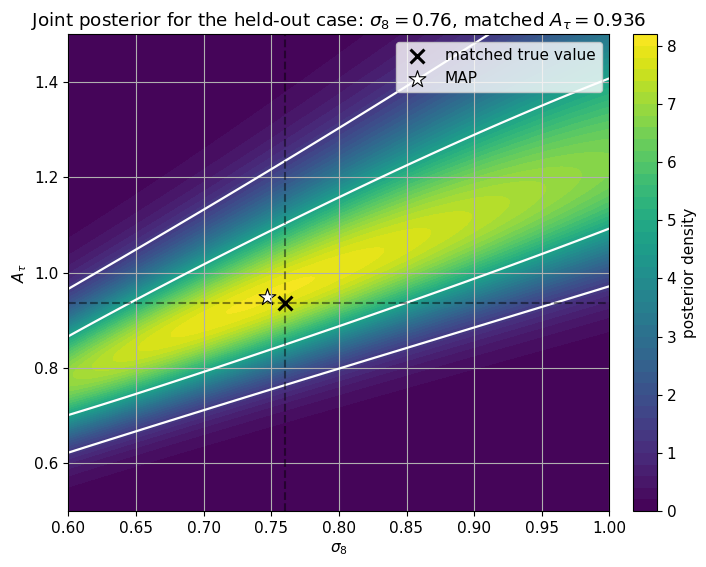

In [238]:
case = inference_cases[0]

fig, ax = plt.subplots(figsize=(7.2, 5.8))

image = ax.contourf(
    sigma8_grid,
    A_tau_grid,
    case["posterior_2d"],
    levels=40,
    cmap="viridis",
)

density_levels = sorted([
    case["posterior_95_level"],
    case["posterior_68_level"],
])

ax.contour(
    sigma8_grid,
    A_tau_grid,
    case["posterior_2d"],
    levels=density_levels,
    colors="white",
    linewidths=1.6,
)

ax.scatter(
    case["true_sigma8"],
    case["true_A_tau"],
    color="black",
    marker="x",
    s=100,
    linewidths=2.2,
    label="matched true value",
)

ax.scatter(
    case["map_sigma8"],
    case["map_A_tau"],
    color="white",
    edgecolor="black",
    marker="*",
    s=160,
    linewidths=0.8,
    label="MAP",
)

ax.axvline(case["true_sigma8"], color="black", linestyle="--", alpha=0.45)
ax.axhline(case["true_A_tau"], color="black", linestyle="--", alpha=0.45)

ax.set_xlabel(r"$\sigma_8$")
ax.set_ylabel(r"$A_\tau$")
ax.set_xlim(SIGMA8_MIN, SIGMA8_MAX)
ax.set_ylim(A_TAU_MIN, A_TAU_MAX)
ax.legend(loc="upper right", frameon=True)

colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label(r"posterior density")

ax.set_title(
    fr"Joint posterior for the held-out case: "
    fr"$\sigma_8={case['true_sigma8']:.2f}$, "
    fr"matched $A_\tau={case['true_A_tau']:.3f}$"
)

plt.tight_layout()
plt.show()

# 16. Conceptual summary

This notebook has demonstrated the structure of a differentiable Lyα forest inference pipeline:

$$
\tau(x)
\longrightarrow
F(x;A_\tau)=e^{-A_\tau\tau(x)}
\longrightarrow
F_{\mathrm{mock}}(x)
\longrightarrow
P_{\mathrm{1D}}(k)
\longrightarrow
m_\phi(\sigma_8,A_\tau)
\longrightarrow
\chi^2(\sigma_8,A_\tau)
\longrightarrow
p(\sigma_8,A_\tau\mid d).
$$

The key ideas are:

1. A simulated spectrum can be converted into a statistical summary.
2. $A_\tau$ changes the optical depth before flux is computed, so it naturally affects the power spectrum.
3. Matching the mean flux helps separate fluctuation-pattern changes from simple mean-flux changes.
4. A double-power-law fit is a useful first differentiable modeling exercise before introducing a neural network.
5. A supervised emulator can learn how the summary changes with both a cosmological parameter and a nuisance parameter.
6. A likelihood compares an observed summary with the model prediction.
7. If the emulator and likelihood are written in PyTorch, the likelihood is differentiable with respect to the physical parameters.
8. Finite differences provide a useful check, but they require choosing a step size.
9. A two-dimensional posterior can reveal degeneracies between a cosmological parameter and a nuisance parameter.

This is still a minimal example, but it shows how differentiable programming can connect model fitting, emulation, gradient-based inference, and posterior exploration.


## Further checks

The following variations help test which parts of the pipeline matter:

1. Decrease `SNR` from 20 to 10 and examine whether the 2D posterior becomes broader.
2. Change `INSTRUMENT_FWHM_KMS` and identify which $k$-modes are most affected.
3. Add more values to `A_TAU_EMULATOR_VALUES` and examine whether the posterior changes smoothly.
4. Widen the allowed prior range for $A_\tau$ only after training the emulator over a wider range.
5. Train the emulator with fewer $\sigma_8$ values and examine whether interpolation becomes worse.
6. Replace the neural-network emulator with a polynomial model in $(\sigma_8,A_\tau)$ and compare the result.
7. Change the target mean flux used in the visual comparison and check how the inferred $A_\tau$ values shift.

Each variation changes one component of the pipeline while leaving the rest fixed. This is the standard way to build intuition about a scientific inference workflow.
